# Step 1.1: Retail Fuel Prices in Cambodia (Open Development Cambodia - ODC)
### Establishing Macroeconomic Freight & Operating Cost Indicators
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Data Source:** Open Development Cambodia (ODC) / Ministry of Commerce (MoC) Retail Gasoline & Diesel Price Notifications.  
**Objective:** Ingest historical gasoline and diesel prices in KHR per liter to establish freight cost indicators, compute fuel price spread (diesel vs regular), and analyze cost shock volatility for MSE transport, supply chain logistics, and generator reliance.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ingest ODC Retail Fuel Price Dataset
gas_path = os.path.join('..', '..', 'data', 'Gasoline price - Gas_EN.csv')
df_gas = pd.read_csv(gas_path)
df_gas["date"] = pd.to_datetime(df_gas["im_date"], format="%d-%m-%Y")
df_gas = df_gas.sort_values("date").reset_index(drop=True)
df_gas["diesel_spread"] = df_gas["diesel_gas"] - df_gas["regu_gas"]
df_gas["freight_cost_index"] = (df_gas["diesel_gas"] / df_gas["diesel_gas"].iloc[0]) * 100

print(f"Date Range: {df_gas['date'].min().strftime('%Y-%m-%d')} to {df_gas['date'].max().strftime('%Y-%m-%d')}")
print(f"Total Observations: {len(df_gas)}")
print(df_gas[['regu_gas', 'diesel_gas', 'diesel_spread', 'freight_cost_index']].describe().round(1))

Date Range: 2026-03-08 to 2026-10-01
Total Observations: 207
       regu_gas  diesel_gas  diesel_spread  freight_cost_index
count     207.0       207.0          207.0               207.0
mean     4782.9      5448.3          665.5               105.8
std       485.4       909.0          606.6                17.7
min      3900.0      4000.0         -100.0                77.7
25%      4400.0      4950.0          150.0                96.1
50%      4800.0      5250.0          650.0               101.9
75%      5225.0      5700.0          850.0               110.7
max      5500.0      8200.0         2700.0               159.2

### 1.1 Historical Fuel Price Trends (KHR/Liter)
Comparison between Regular Gasoline (urban deliveries/tuk-tuks) and Diesel (freight & heavy transport).

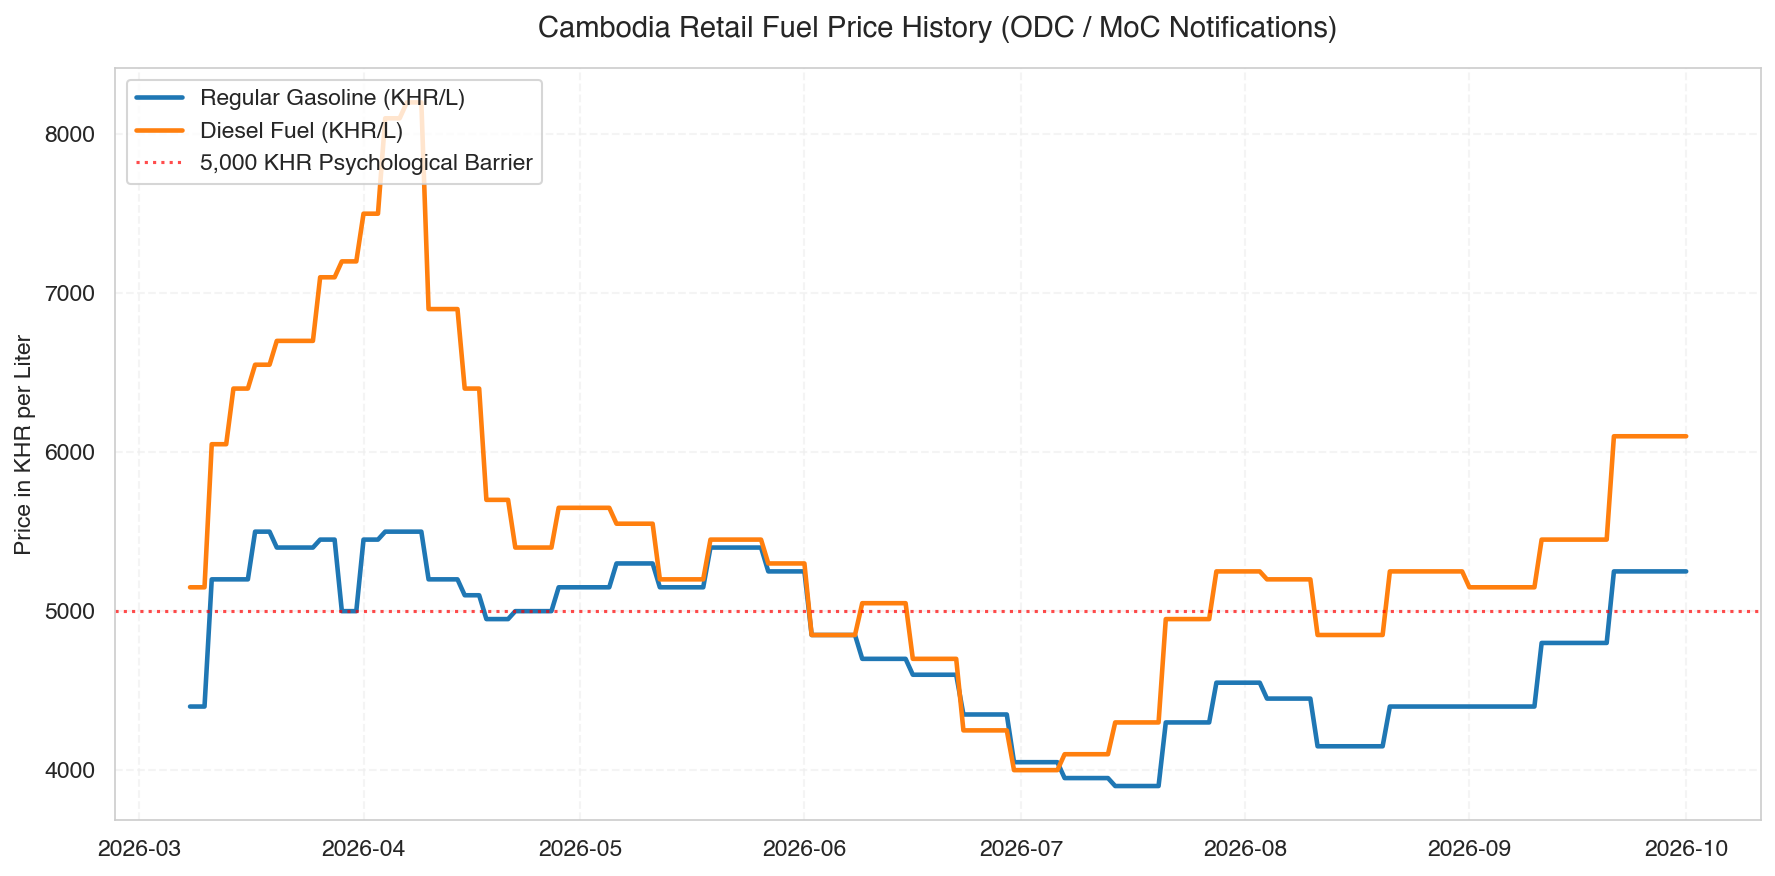

In [ ]:
# Plot Retail Fuel Price Evolution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_gas["date"], df_gas["regu_gas"], label="Regular Gasoline (KHR/L)", color="#1f77b4", linewidth=2.2)
ax.plot(df_gas["date"], df_gas["diesel_gas"], label="Diesel Fuel (KHR/L)", color="#ff7f0e", linewidth=2.2)
ax.set_title("Cambodia Retail Fuel Price History (ODC / MoC Notifications)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Price in KHR per Liter", fontsize=11)
ax.axhline(5000, color="red", linestyle=":", alpha=0.7, label="5,000 KHR Psychological Barrier")
ax.legend(loc="upper left")
plt.show()

### 1.2 Freight Cost Indicator & Diesel Premium
Diesel powers commercial freight trucks, river barges, and MSE backup generators. Positive spread indicates freight margin squeeze.

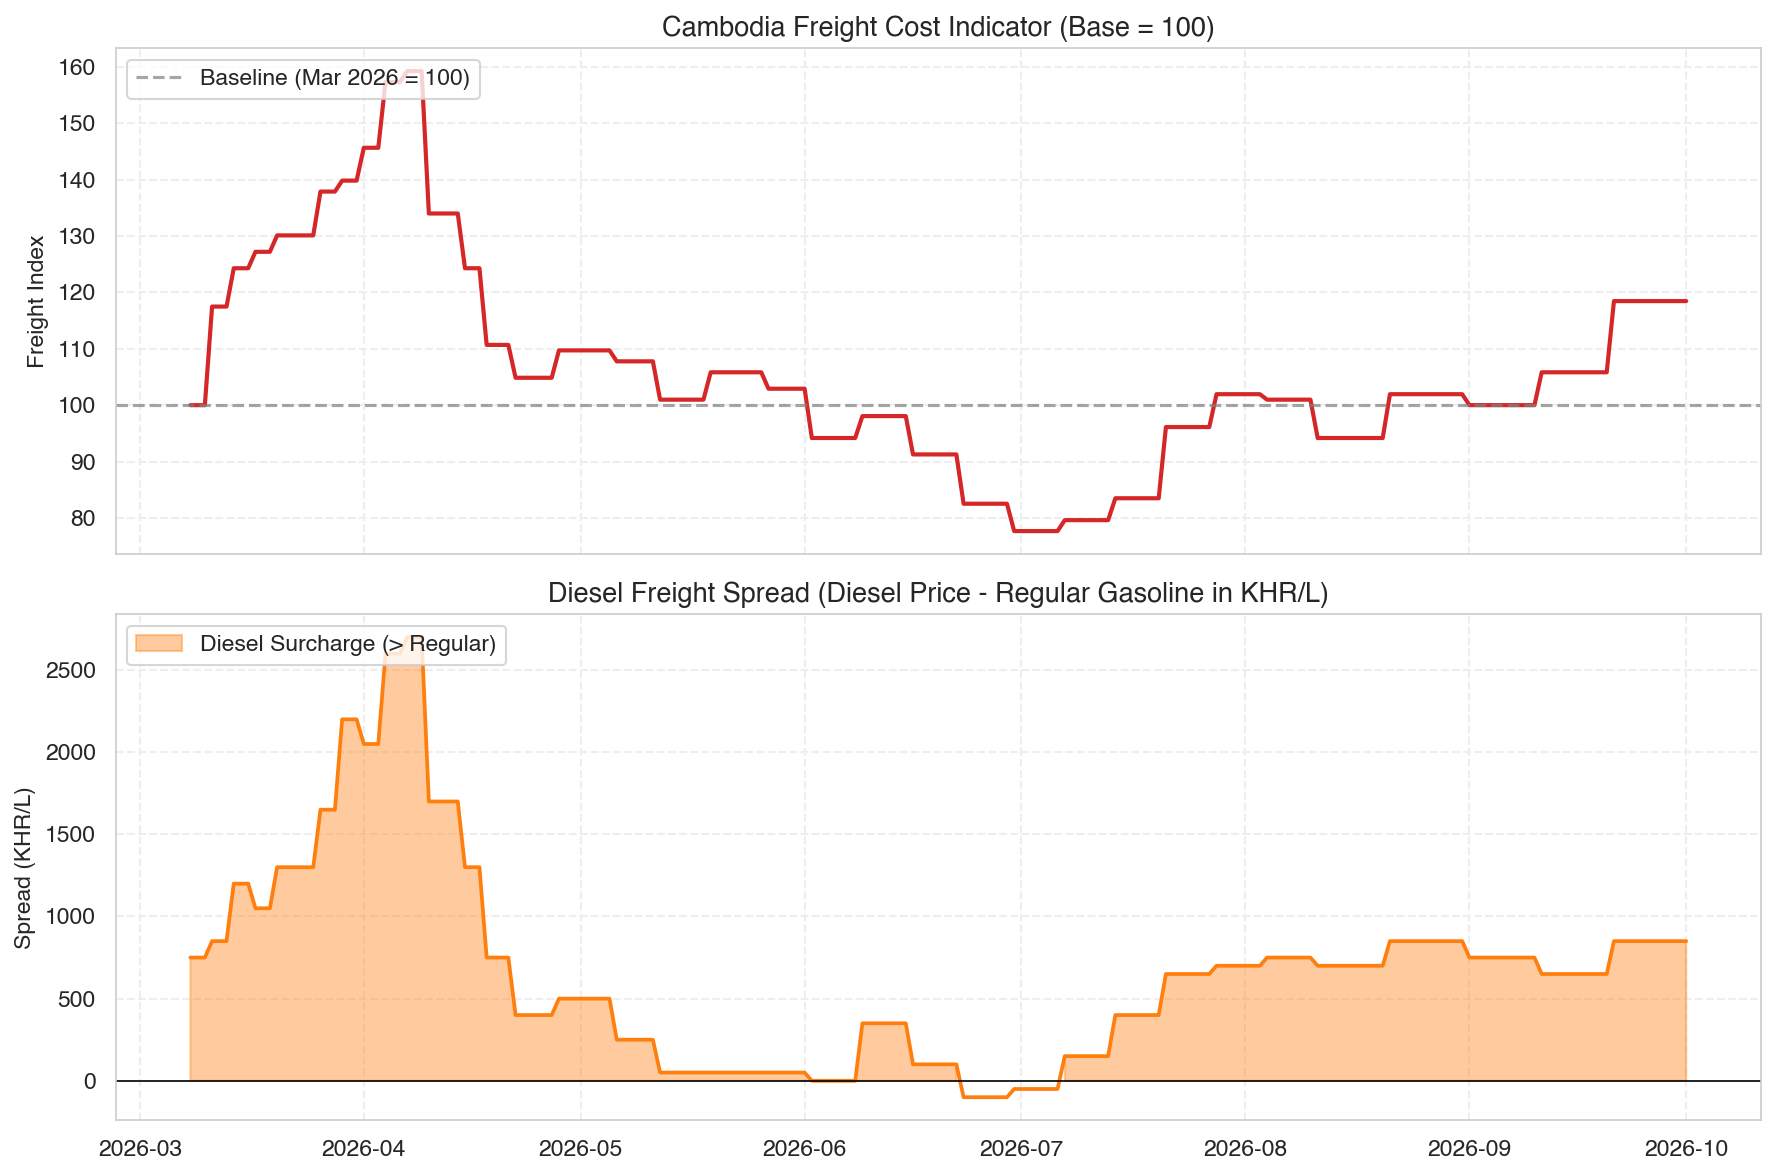

In [ ]:
# Freight Cost Index & Diesel Spread
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(df_gas["date"], df_gas["freight_cost_index"], color="#d62728", linewidth=2)
ax1.axhline(100, color="grey", linestyle="--", label="Baseline (Mar 2026 = 100)")
ax1.set_title("Cambodia Freight Cost Indicator (Base = 100)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Freight Index")

ax2.fill_between(df_gas["date"], 0, df_gas["diesel_spread"], 
                 where=(df_gas["diesel_spread"] >= 0), color="#ff7f0e", alpha=0.4, label="Diesel Surcharge")
ax2.plot(df_gas["date"], df_gas["diesel_spread"], color="#ff7f0e", linewidth=1.8)
ax2.set_title("Diesel Freight Spread (Diesel - Regular)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Spread (KHR/L)")
plt.show()

### 1.3 MoC Notification Price Shock Analysis
Bi-weekly rate of change across Ministry of Commerce notices. Hikes > 5% trigger operational alerts.

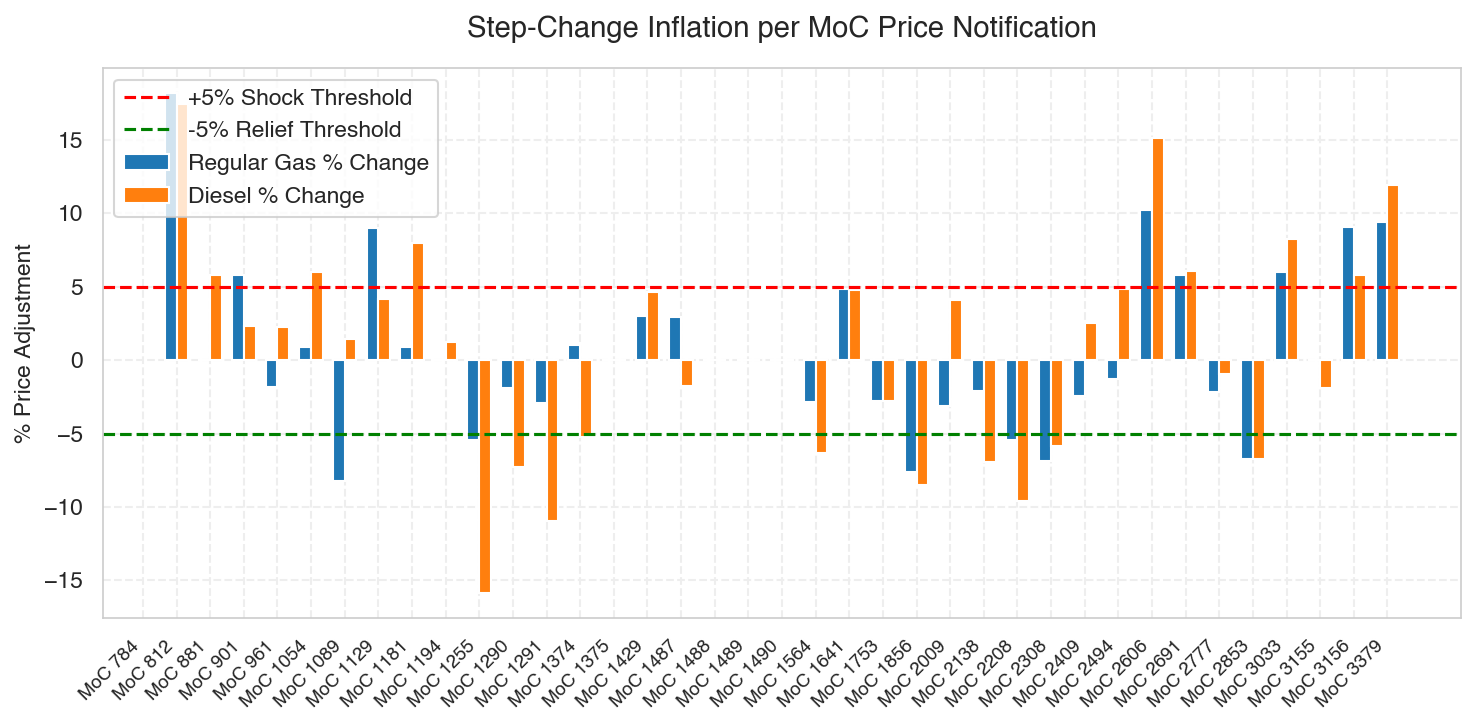

In [ ]:
# Notification Price Adjustments
import matplotlib.pyplot as plt
notifs = df_gas.drop_duplicates(subset=["moc_no"]).sort_values("date").reset_index(drop=True)
notifs["diesel_pct_change"] = notifs["diesel_gas"].pct_change() * 100
notifs["gas_pct_change"] = notifs["regu_gas"].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(notifs))
ax.bar(x - 0.17, notifs["gas_pct_change"], width=0.35, label="Regular Gas %", color="#1f77b4")
ax.bar(x + 0.17, notifs["diesel_pct_change"], width=0.35, label="Diesel %", color="#ff7f0e")
ax.axhline(5, color="red", linestyle="--", label="+5% Shock Threshold")
ax.axhline(-5, color="green", linestyle="--", label="-5% Relief Threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"MoC {int(m)}" for m in notifs["moc_no"]], rotation=45)
ax.set_title("Step-Change Inflation per MoC Price Notification", fontsize=14, fontweight='bold')
ax.legend()
plt.show()

### Step 1.1 Findings for Macro Freight Indicators
1. **Diesel High Beta:** Diesel swung widely from **4,000 KHR to 8,200 KHR/L** (variance = 909 KHR), representing a **+105% peak swing**, compared to Regular Gasoline (3,900 to 5,500 KHR/L).
2. **Freight Cost Indicator:** When diesel spiked above 6,000 KHR/L, logistics operators and MSE distributors experienced severe margin compression because urban MSE retail pricing is sticky and cannot easily pass fuel surcharges to consumers.
